# 01 - EDA - Predicción de reingreso hospitalario en pacientes diabéticos

EDA sobre el dataset de UCI. No se modifica el CSV crudo, todo lo reutilizable
queda en `src/data/` y `src/eda/`.

In [3]:
# =====================================================================
# Setup — funciona tanto en local (VS Code/Jupyter) como en Google Colab
# =====================================================================
import importlib
import os
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/mzc07/diabetes-readmission-predictor.git"
    REPO_BRANCH = "develop"
    REPO_DIR = Path("/content/diabetes-readmission-predictor")

    if not REPO_DIR.exists():
        subprocess.run(
            ["git", "clone", "--branch", REPO_BRANCH, "--depth", "1", REPO_URL, str(REPO_DIR)],
            check=True,
        )
    else:
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=True)

    # Nos ubicamos en notebooks/ para que las rutas relativas del resto del
    # notebook (../data/raw/..., ../reports/figures) funcionen igual que en local.
    os.chdir(REPO_DIR / "notebooks")

    %pip install -q numpy pandas scikit-learn matplotlib seaborn

# %load_ext autoreload
# %autoreload 2

sys.path.insert(0, str(Path.cwd().parent))  # para poder importar src/ desde notebooks/

import src.data.loader
import src.data.quality
import src.eda.univariate
import src.eda.bivariate
import src.eda.relevance

# Force reload modules
importlib.reload(src.data.loader)
importlib.reload(src.data.quality)
importlib.reload(src.eda.univariate)
importlib.reload(src.eda.bivariate)
importlib.reload(src.eda.relevance)

# Los módulos se importaban pero las funciones se usaban sin prefijo más abajo
# (habría fallado con NameError). Se traen los nombres explícitamente:
from src.data.loader import load_diabetic_data, load_id_mappings, ID_COLUMNS, validate_schema
from src.data.quality import (
    duplicate_report,
    missing_value_report,
    sentinel_value_scan,
    numeric_out_of_range_report,
)
from src.eda.univariate import target_distribution, numeric_summary, categorical_summary
from src.eda.bivariate import (
    correlation_matrix,
    high_correlation_pairs,
    categorical_vs_target_chi2,
    numeric_vs_target_test,
)
from src.eda.relevance import mutual_info_ranking, cramers_v_ranking

sns.set_theme(style="whitegrid")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)


## Fase 0 — Preparación

In [4]:
df = load_diabetic_data("../data/raw/diabetic_data.csv")
mappings = load_id_mappings("../data/raw/IDS_mapping.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
df.dtypes.value_counts()

,count
object,37
int64,13


**Nota:** `admission_type_id`, `discharge_disposition_id` y `admission_source_id`
son categoricas codificadas como enteros, su significado esta en `IDS_mapping.csv`.
Por eso las mostramos decodificadas.

In [7]:
for name, table in mappings.items():
    print(f"--- {name} ---")
    display(table)

--- admission_type_id ---


,id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NULL
6,7,Trauma Center
7,8,Not Mapped


--- discharge_disposition_id ---


,id,description
0,1,Discharged to home
1,2,Discharged/transferred to another short term h...
2,3,Discharged/transferred to SNF
3,4,Discharged/transferred to ICF
4,5,Discharged/transferred to another type of inpa...
5,6,Discharged/transferred to home with home healt...
6,7,Left AMA
7,8,Discharged/transferred to home under care of H...
8,9,Admitted as an inpatient to this hospital
9,10,Neonate discharged to another hospital for neo...


--- admission_source_id ---


,id,description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)
5,6,Transfer from another health care facility
6,7,Emergency Room
7,8,Court/Law Enforcement
8,9,Not Available
9,10,Transfer from critial access hospital


In [8]:
problems = validate_schema(df)
if problems:
    for p in problems:
        print("- ", p)
else:
    print("Esquema validado sin problemas.")

Esquema validado sin problemas.


**Duplicados y llaves.** `encounter_id` debe ser unico (una fila = un encuentro).
`patient_nbr` no debe serlo, un mismo paciente puede tener varias hospitalizaciones,
por eso el split se hace agrupado por paciente.

In [9]:
dup_report = duplicate_report(df, key_columns=ID_COLUMNS)
dup_report

{'filas_totales': 101766,
 'filas_duplicadas_completas': 0,
 'encounter_id_valores_unicos': 101766,
 'encounter_id_max_repeticiones': 1,
 'encounter_id_pacientes_con_mas_de_1_encuentro': 0,
 'patient_nbr_valores_unicos': 71518,
 'patient_nbr_max_repeticiones': 40,
 'patient_nbr_pacientes_con_mas_de_1_encuentro': 16773}

## Fase 1 — Calidad de datos

### Valores faltantes

In [10]:
missing = missing_value_report(df)
missing[missing["pct_faltante"] > 0]

,pct_faltante,accion_sugerida
weight,96.858479,eliminar
max_glu_serum,94.746772,eliminar
A1Cresult,83.277322,evaluar binaria 'es_nulo'
medical_specialty,49.082208,evaluar binaria 'es_nulo'
payer_code,39.557416,evaluar binaria 'es_nulo'
race,2.233555,imputar
diag_3,1.398306,imputar
diag_2,0.351787,imputar
diag_1,0.020636,imputar


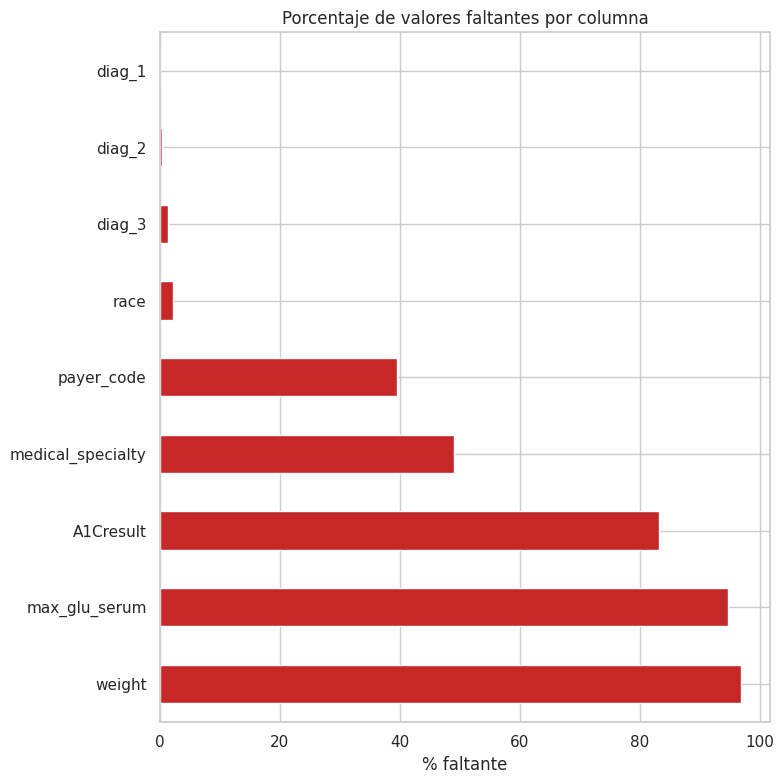

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
faltantes = missing[missing["pct_faltante"] > 0]["pct_faltante"]
faltantes.plot(kind="barh", ax=ax, color="#c62828")
ax.set_xlabel("% faltante")
ax.set_title("Porcentaje de valores faltantes por columna")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_missing_values.png", dpi=150)
plt.show()

**Lectura:** `weight` (~97%) es candidata a eliminar. `medical_specialty` (~49%) y
`payer_code` (~40%) estan en un rango medio, se podria evaluar una columna
binaria de "es nulo" antes de imputar directamente.

### Valores centinela

El loader ya convierte los centinelas conocidos (`?`, `Not Available`, `NULL`, `Not Mapped`)
en NaN. Este escaneo es solo para revisar si queda algo suelto.

In [12]:
sentinel_value_scan(df)

,columna,centinelas_encontrados
0,gender,{'Unknown/Invalid': 3}


### Consistencia de tipos y outliers

In [13]:
rangos_esperados = {
    "time_in_hospital": (1, 14),
    "num_lab_procedures": (0, 150),
    "num_procedures": (0, 10),
    "num_medications": (0, 100),
    "number_outpatient": (0, 50),
    "number_emergency": (0, 50),
    "number_inpatient": (0, 30),
    "number_diagnoses": (1, 20),
}
numeric_out_of_range_report(df, rangos_esperados)

,columna,rango_esperado,min_real,max_real,filas_fuera_de_rango
0,time_in_hospital,"(1, 14)",1,14,0
1,num_lab_procedures,"(0, 150)",1,132,0
2,num_procedures,"(0, 10)",0,6,0
3,num_medications,"(0, 100)",1,81,0
4,number_outpatient,"(0, 50)",0,42,0
5,number_emergency,"(0, 50)",0,76,4
6,number_inpatient,"(0, 30)",0,21,0
7,number_diagnoses,"(1, 20)",1,16,0


## Fase 2 - Análisis univariado

### Target

Se define el target binario `readmitted_lt30` para usarlo en el resto del análisis.

In [14]:
df["readmitted_lt30"] = df["readmitted"] == "<30"
target_distribution(df, target_col="readmitted")

proporcion
original NO                       0.5391
         >30                      0.3493
         <30                      0.1116
binario  resto                    0.8884
         readmitido <30 días      0.1116

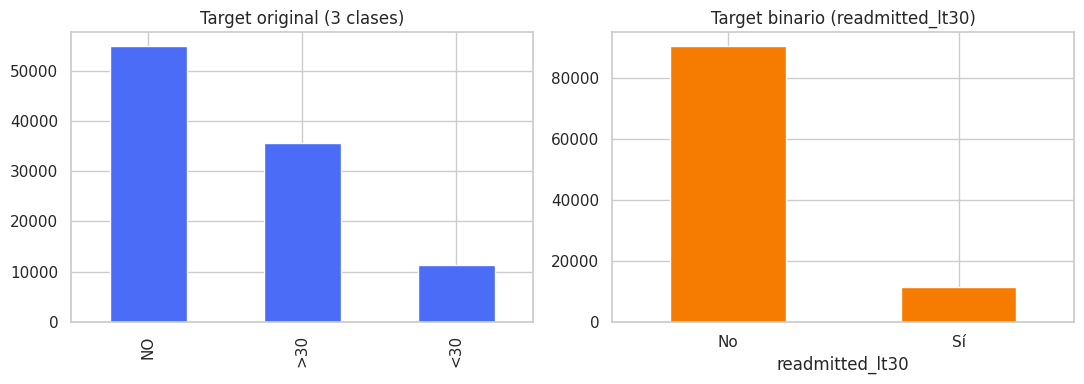

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["readmitted"].value_counts().plot(kind="bar", ax=axes[0], color="#4a6cf7")
axes[0].set_title("Target original (3 clases)")
axes[0].set_xlabel("")

df["readmitted_lt30"].value_counts().plot(kind="bar", ax=axes[1], color="#f57c00")
axes[1].set_title("Target binario (readmitted_lt30)")
axes[1].set_xticklabels(["No", "Sí"], rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_target_distribution.png", dpi=150)
plt.show()

**Desbalance:** cerca del 11% de los encuentros terminan en reingreso &lt;30 días.

### Variables numéricas clave

In [16]:
numeric_cols = [
    "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses",
]
numeric_summary(df, numeric_cols)

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,kurtosis
time_in_hospital,101766.0,4.395987,2.985108,1.0,1.0,2.0,4.0,6.0,14.0,14.0,1.133999,0.850251
num_lab_procedures,101766.0,43.095641,19.674362,1.0,1.0,31.0,44.0,57.0,85.0,132.0,-0.236544,-0.245074
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,0.0,1.0,2.0,6.0,6.0,1.316415,0.857110
num_medications,101766.0,16.021844,8.127566,1.0,3.0,10.0,15.0,20.0,43.0,81.0,1.326672,3.468155
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,0.0,5.0,42.0,8.832959,147.907736
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,0.0,3.0,76.0,22.855582,1191.686726
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,0.0,1.0,6.0,21.0,3.614139,20.719397
number_diagnoses,101766.0,7.422607,1.933600,1.0,2.0,6.0,8.0,9.0,9.0,16.0,-0.876746,-0.079056


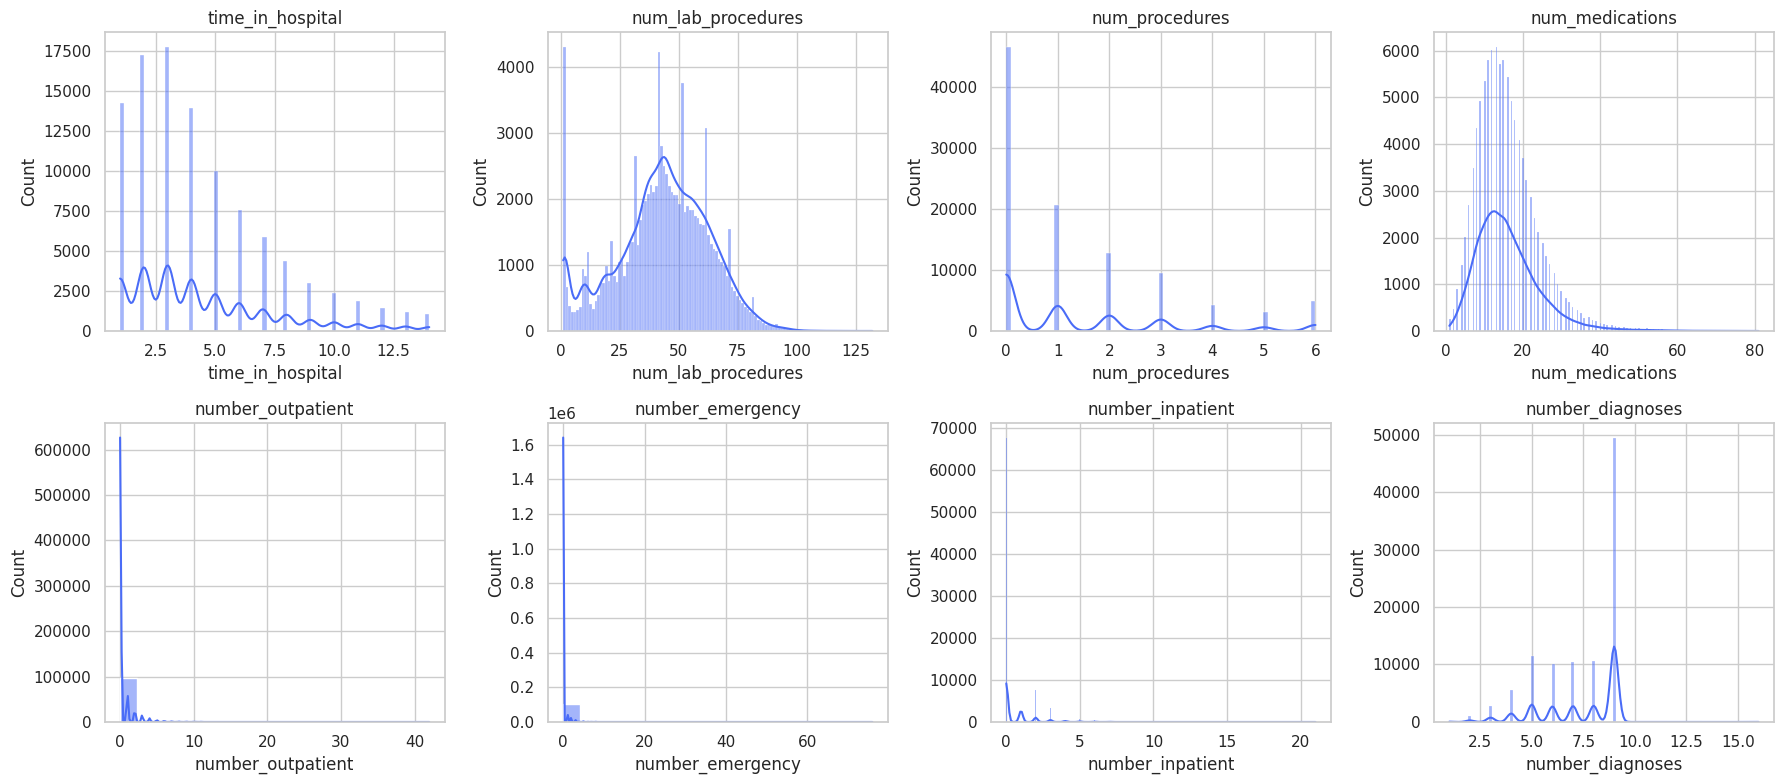

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4a6cf7")
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_numeric_distributions.png", dpi=150)
plt.show()

**Lectura:** `number_outpatient`, `number_emergency` y `number_inpatient` están muy
sesgadas a la derecha (la mayoría en 0), es normal en conteos de eventos raros.

### Variables categóricas

In [18]:
categorical_cols = [
    "race", "gender", "age", "admission_type_id", "discharge_disposition_id",
    "admission_source_id", "medical_specialty", "max_glu_serum", "A1Cresult",
    "insulin", "change", "diabetesMed",
]
categorical_summary(df, categorical_cols)

,columna,cardinalidad,top_categorias
0,race,5,"{'Caucasian': 0.748, 'AfricanAmerican': 0.189,..."
1,gender,3,"{'Female': 0.538, 'Male': 0.462, 'Unknown/Inva..."
2,age,10,"{'[70-80)': 0.256, '[60-70)': 0.221, '[50-60)'..."
3,admission_type_id,8,"{1: 0.531, 3: 0.185, 2: 0.182, 6: 0.052, 5: 0...."
4,discharge_disposition_id,26,"{1: 0.592, 3: 0.137, 6: 0.127, 18: 0.036, 2: 0..."
5,admission_source_id,17,"{7: 0.565, 1: 0.291, 17: 0.067, 4: 0.031, 6: 0..."
6,medical_specialty,72,"{nan: 0.491, 'InternalMedicine': 0.144, 'Emerg..."
7,max_glu_serum,3,"{nan: 0.947, 'Norm': 0.026, '>200': 0.015, '>3..."
8,A1Cresult,3,"{nan: 0.833, '>8': 0.081, 'Norm': 0.049, '>7':..."
9,insulin,4,"{'No': 0.466, 'Steady': 0.303, 'Down': 0.12, '..."


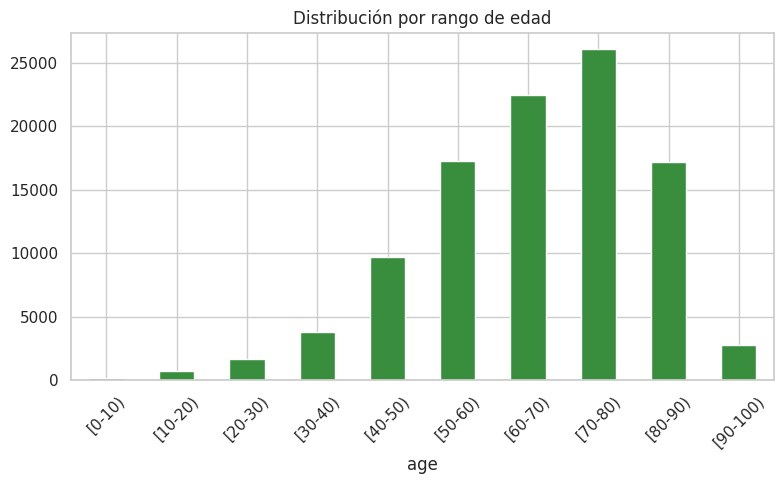

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
orden_edad = sorted(df["age"].dropna().unique(), key=lambda x: int(x.strip("[)").split("-")[0]))
df["age"].value_counts().reindex(orden_edad).plot(kind="bar", ax=ax, color="#388e3c")
ax.set_title("Distribución por rango de edad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_age_distribution.png", dpi=150)
plt.show()

## Fase 3 — Análisis bivariado / multivariado

### Numérica vs. numérica

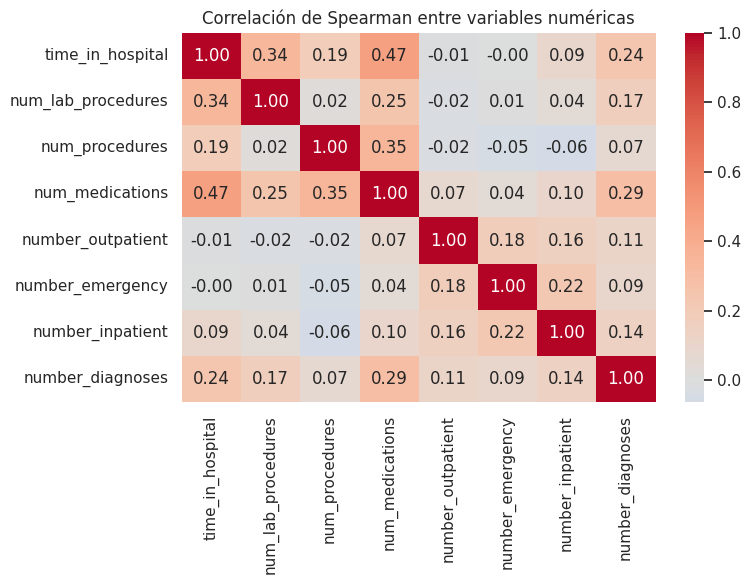

In [20]:
corr = correlation_matrix(df, numeric_cols, method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación de Spearman entre variables numéricas")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_correlation_heatmap.png", dpi=150)
plt.show()

In [21]:
high_correlation_pairs(corr, threshold=0.8)

,variable_1,variable_2,correlacion


### Categórica vs. target

In [22]:
chi2_results = categorical_vs_target_chi2(df, categorical_cols, target_col="readmitted")
chi2_results

,columna,chi2,p_valor,dof
4,discharge_disposition_id,3587.29,0.000000e+00,50
6,medical_specialty,1218.77,1.840428e-170,142
5,admission_source_id,1150.97,2.317985e-221,32
9,insulin,516.70,2.126586e-108,6
3,admission_type_id,415.76,6.037493e-80,14
11,diabetesMed,386.51,1.175514e-84,2
2,age,313.17,9.348415e-56,18
10,change,215.83,1.362061e-47,2
0,race,94.39,5.957899e-17,8
1,gender,37.46,1.447272e-07,4


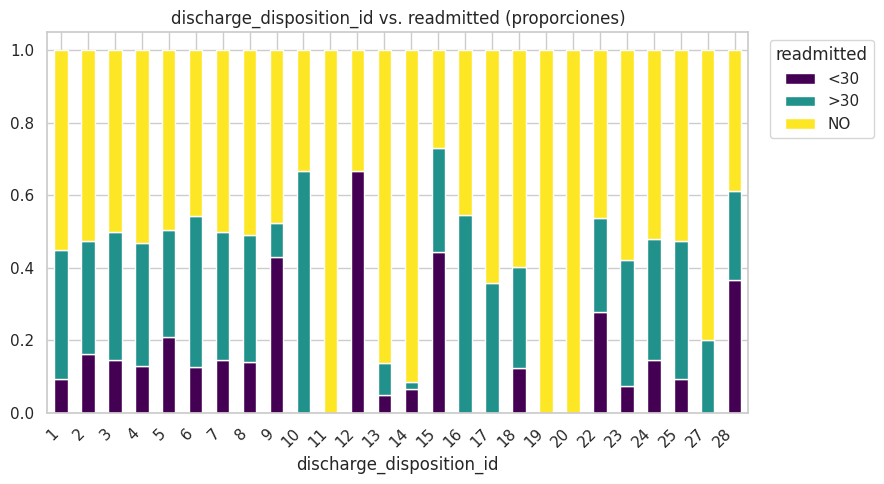

In [23]:
top_cat = chi2_results.iloc[0]["columna"]
tabla = pd.crosstab(df[top_cat], df["readmitted"], normalize="index")

fig, ax = plt.subplots(figsize=(9, 5))
tabla.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title(f"{top_cat} vs. readmitted (proporciones)")
ax.legend(title="readmitted", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_top_categorical_vs_target.png", dpi=150)
plt.show()

### Numérica vs. target

In [24]:
num_vs_target = numeric_vs_target_test(df, numeric_cols, target_binary_col="readmitted_lt30")
num_vs_target

,columna,mediana_readmitido_lt30,mediana_resto,p_valor
6,number_inpatient,0.0,0.0,0.000000e+00
5,number_emergency,0.0,0.0,4.613076e-91
0,time_in_hospital,4.0,4.0,2.689648e-59
7,number_diagnoses,9.0,8.0,2.677772e-51
3,num_medications,16.0,15.0,1.394205e-47
4,number_outpatient,0.0,0.0,1.151406e-27
1,num_lab_procedures,45.0,44.0,5.376925e-11
2,num_procedures,1.0,1.0,5.115273e-02


/tmp/ipykernel_1475/1678315610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="readmitted_lt30", y=col, ax=ax, palette=["#4a6cf7", "#f57c00"])
/tmp/ipykernel_1475/1678315610.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Sí"])
/tmp/ipykernel_1475/1678315610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="readmitted_lt30", y=col, ax=ax, palette=["#4a6cf7", "#f57c00"])
/tmp/ipykernel_1475/1678315610.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xtickl

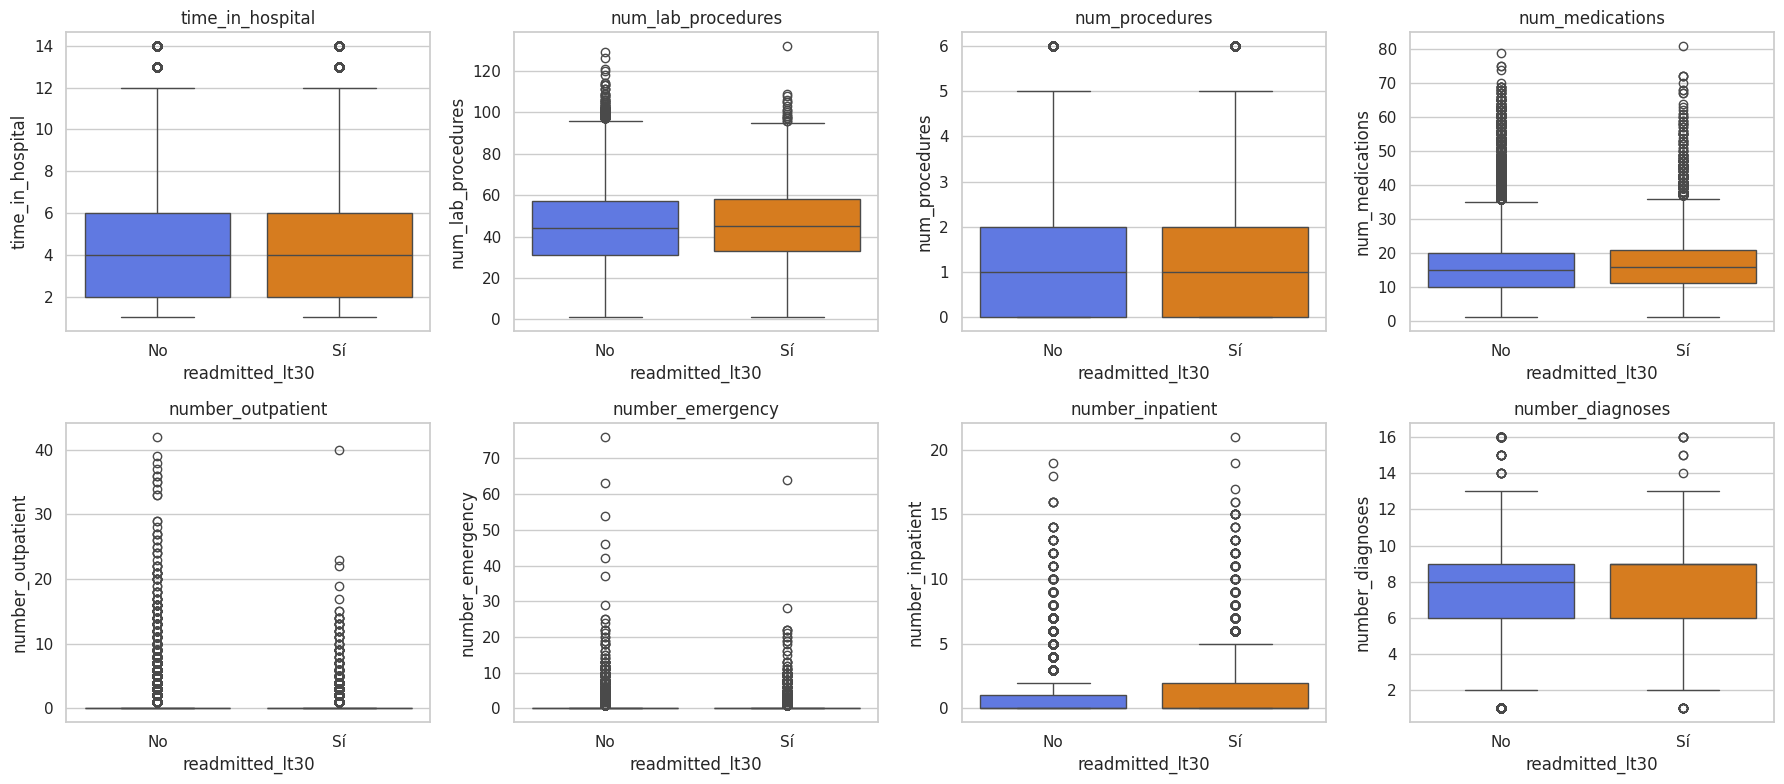

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=df, x="readmitted_lt30", y=col, ax=ax, palette=["#4a6cf7", "#f57c00"])
    ax.set_xticklabels(["No", "Sí"])
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_numeric_vs_target_boxplots.png", dpi=150)
plt.show()

## Fase 4 (parcial) - Ranking de relevancia

Solo la parte estadística (mutual information, Cramér's V). La importancia por
árboles y SHAP se hace después, en el notebook de modelado.

In [26]:
mi_ranking = mutual_info_ranking(df, numeric_cols, target_binary_col="readmitted_lt30")
mi_ranking

,columna,mutual_info
0,number_inpatient,0.011243
1,number_diagnoses,0.008315
2,time_in_hospital,0.003897
3,number_emergency,0.003876
4,number_outpatient,0.001722
5,num_medications,0.001485
6,num_procedures,0.001374
7,num_lab_procedures,0.000000


In [27]:
cv_ranking = cramers_v_ranking(df, categorical_cols, target_col="readmitted")
cv_ranking

,columna,cramers_v
0,discharge_disposition_id,0.133
1,medical_specialty,0.082
2,admission_source_id,0.075
3,diabetesMed,0.062
4,insulin,0.050
5,change,0.046
6,admission_type_id,0.045
7,age,0.039
8,race,0.037
9,A1Cresult,0.019


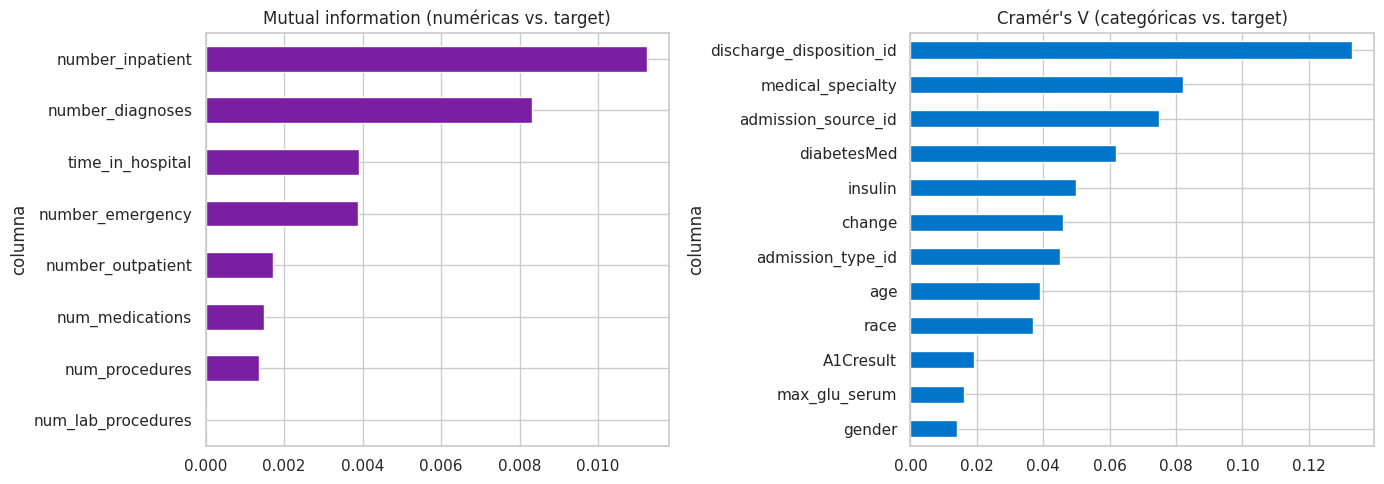

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mi_ranking.set_index("columna")["mutual_info"].plot(kind="barh", ax=axes[0], color="#7b1fa2")
axes[0].set_title("Mutual information (numéricas vs. target)")
axes[0].invert_yaxis()

cv_ranking.set_index("columna")["cramers_v"].plot(kind="barh", ax=axes[1], color="#0075ca")
axes[1].set_title("Cramér's V (categóricas vs. target)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_relevance_ranking.png", dpi=150)
plt.show()

## Notas para la siguiente etapa

- Eliminar `weight` (~97% nula).
- Evaluar columna binaria "es_nulo" para `medical_specialty` y `payer_code`.
- Imputar el resto de columnas con nulos residuales.
- Split agrupado por `patient_nbr` (hay pacientes con más de un encuentro).
- Clases desbalanceadas (~11% positivos), usar class_weight balanceado y mirar
  Recall/F1/ROC-AUC en vez de accuracy.
- Revisar pares con correlación > 0.8 antes de usar modelos lineales.
- `diag_1/2/3` quedan pendientes de agrupar por código ICD-9, por eso no se
  analizan aquí como categóricas (tienen demasiadas categorías sin agrupar).
- Ver `mi_ranking` y `cv_ranking` arriba para las variables con más señal.